# 03 - Imbalanced learning

**Purpose:** learn how to build and evaluate classifiers when the important class is rare.

In this notebook we work with the Bank Marketing dataset, where the positive outcome (`y = yes`) is much less common than the negative outcome. The practical question is not only "which model scores highest?" It is "which modeling and decision strategy gives a useful trade-off between missed positives, false alarms, probability quality, simplicity, speed, and maintainability?"

**Estimated time:** 100-140 minutes  
**Prerequisites:** notebooks 00-02; cross-validation, metrics, and pipelines.  
**Depends on:** the split contract from notebook 00 and feature pipeline from notebook 02.

## Learning objectives

By the end, students should be able to:

- Diagnose class imbalance and explain why accuracy is a weak default metric.
- Compare a majority-class dummy model, plain logistic regression, class weighting, random resampling, SMOTE, and SMOTENC.
- Put all preprocessing and resampling inside pipelines to avoid leakage.
- Separate ranking quality, threshold behavior, probability calibration, and business cost.
- Make a practical model recommendation instead of chasing one metric.

**Teaching note:** Ask students what a bank would rather tolerate: calling too many unlikely customers, or missing customers who would subscribe. Their answer defines the cost assumptions, not the algorithm.


## Concept: what imbalance changes

Imbalanced learning is not a special algorithm so much as a decision problem with rare positives. Several things can go wrong:

- A model can look accurate by predicting the majority class almost always.
- A threshold of `0.50` may be too conservative when positives are rare.
- Resampling can improve recall but distort the probability scale.
- Synthetic examples can be invalid when categorical values, time order, or domain constraints are not respected.

We will start with simple baselines and add complexity only when it teaches a clear trade-off.


## Setup

This cell defines the same small course utilities used in earlier notebooks. They are embedded so the notebook can run on its own in class. The important contract is that `duration` is dropped by default because it is only known after a marketing call, so using it would leak future information into training.


In [1]:
import hashlib, json, os, platform, random, warnings
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

# These UI/interoperability warnings do not change the lesson results.
warnings.filterwarnings("ignore", message="X does not have valid feature names, but LGBMClassifier")
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (average_precision_score, confusion_matrix, log_loss,
                             precision_score, recall_score, roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
TARGET = "y"
LEAKAGE_COLUMNS = ["duration"]

def project_root():
    return ROOT

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

def fast_mode():
    # Set FAST_MODE=0 for full-size experiments; laptop mode is the default.
    return os.getenv("FAST_MODE", "1").lower() not in {"0", "false", "no"}

def bank_data_path():
    path = project_root() / "data" / "raw" / "bank-full.csv"
    if not path.is_file():
        raise FileNotFoundError(
            f"Expected the bundled Bank Marketing data at {path}. "
            "Run the notebook from the course root or place bank-full.csv there."
        )
    return path

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

def load_bank_data(include_duration=False):
    frame = pd.read_csv(bank_data_path(), sep=";")
    frame[TARGET] = frame[TARGET].map({"no": 0, "yes": 1}).astype("int8")
    if not include_duration:
        frame = frame.drop(columns=LEAKAGE_COLUMNS)
    return frame

def stratified_sample(frame, n, seed=SEED):
    if n >= len(frame):
        return frame.copy()
    fractions = frame[TARGET].value_counts(normalize=True)
    counts = (fractions * n).round().astype(int)
    counts.iloc[0] += n - counts.sum()
    parts = [group.sample(n=min(counts.loc[label], len(group)), random_state=seed + int(label))
             for label, group in frame.groupby(TARGET)]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

def make_splits(frame=None, reduced=None):
    # Deterministic 60/20/20 split. The test set stays sealed until notebook 09.
    from sklearn.model_selection import train_test_split
    frame = load_bank_data() if frame is None else frame
    train_val, test = train_test_split(
        frame, test_size=0.20, stratify=frame[TARGET], random_state=SEED)
    train, validation = train_test_split(
        train_val, test_size=0.25, stratify=train_val[TARGET], random_state=SEED)
    reduced = fast_mode() if reduced is None else reduced
    if reduced:
        train = stratified_sample(train, 12_000)
        validation = stratified_sample(validation, 4_000, SEED + 1)
        test = stratified_sample(test, 4_000, SEED + 2)
    return tuple(part.reset_index(drop=True) for part in (train, validation, test))

def split_xy(frame):
    return frame.drop(columns=TARGET), frame[TARGET]

def feature_groups(frame):
    features = frame.drop(columns=[TARGET], errors="ignore")
    categorical = features.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numerical = features.select_dtypes(include=np.number).columns.tolist()
    return numerical, categorical

def make_preprocessor(frame, scale_numeric=True):
    # Fitted only inside an enclosing pipeline, so validation folds remain untouched.
    numerical, categorical = feature_groups(frame)
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                 min_frequency=10, sparse_output=True)),
    ])
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numerical),
        ("categorical", categorical_pipe, categorical),
    ], sparse_threshold=0.3)

def classification_metrics(y_true, probability, threshold=0.5):
    prediction = np.asarray(probability) >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {"roc_auc": roc_auc_score(y_true, probability),
            "pr_auc": average_precision_score(y_true, probability),
            "log_loss": log_loss(y_true, probability),
            "precision": precision_score(y_true, prediction, zero_division=0),
            "recall": recall_score(y_true, prediction, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "cost": float(fp + 5 * fn)}

def threshold_table(y_true, probability, thresholds=None):
    thresholds = np.linspace(0.05, 0.80, 76) if thresholds is None else thresholds
    return pd.DataFrame([{"threshold": float(t),
                          **classification_metrics(y_true, probability, float(t))}
                         for t in thresholds])

def add_domain_features(frame):
    result = frame.copy()
    result["was_previously_contacted"] = (result["pdays"] != -1).astype("int8")
    result["pdays_clean"] = result["pdays"].replace(-1, np.nan)
    result["contact_pressure"] = result["campaign"] / (1 + result["previous"])
    result["balance_per_age"] = result["balance"] / result["age"].clip(lower=18)
    result["age_band"] = pd.cut(result["age"], bins=[0, 29, 39, 49, 59, np.inf],
                                labels=["<30", "30s", "40s", "50s", "60+"]).astype("object")
    return result.drop(columns=["pdays"])

def environment_metadata():
    import sklearn
    return {"python": platform.python_version(), "platform": platform.platform(),
            "numpy": np.__version__, "pandas": pd.__version__,
            "scikit_learn": sklearn.__version__}

def write_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")

set_seed(SEED)
FAST_MODE = fast_mode()
CV_FOLDS = 3 if FAST_MODE else 5
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
print({"FAST_MODE": FAST_MODE, "CV_FOLDS": CV_FOLDS, "seed": SEED})


{'FAST_MODE': True, 'CV_FOLDS': 3, 'seed': 42}


## Data loading and class audit

We create a development split for cross-validation and a validation split for one final check in this notebook. The sealed test split is created by the utility for consistency, but we do not inspect or use it here.

**Discussion prompt:** If only about 10-12% of customers subscribe, what accuracy could a model get by always predicting "no"? Why would that be useless operationally?


In [2]:
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.metrics import make_scorer
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC
from imblearn.under_sampling import RandomUnderSampler

data = load_bank_data()
development, validation, _sealed_test = make_splits(data, reduced=FAST_MODE)
X_dev, y_dev = split_xy(development)
X_val, y_val = split_xy(validation)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

class_audit = pd.DataFrame({
    "development": y_dev.value_counts().sort_index(),
    "validation": y_val.value_counts().sort_index(),
}).rename(index={0: "no", 1: "yes"})
class_audit["development_rate"] = class_audit["development"] / len(y_dev)
class_audit["validation_rate"] = class_audit["validation"] / len(y_val)

display(class_audit)
print(f"Positive-class prevalence in development data: {y_dev.mean():.3f}")


,development,validation,development_rate,validation_rate
y,,,,
no,10596,3532,0.883,0.883
yes,1404,468,0.117,0.117


Positive-class prevalence in development data: 0.117


The validation prevalence should be close to the development prevalence because the split is stratified. This does not solve imbalance; it only makes the evaluation more stable and representative.


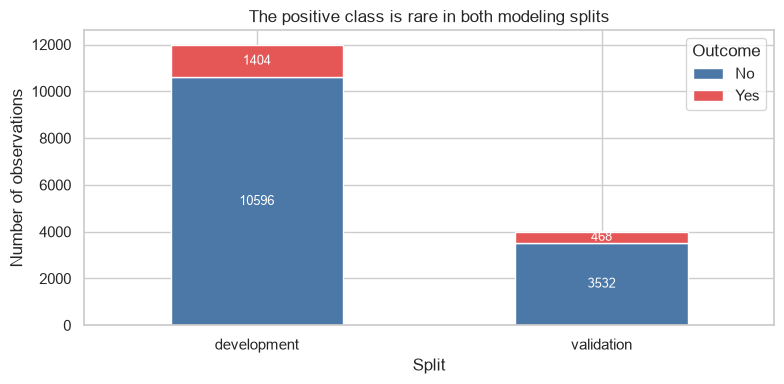

In [3]:
class_plot = class_audit[["development", "validation"]].T
ax = class_plot.plot(kind="bar", stacked=True, figsize=(8, 4),
                     color=["#4C78A8", "#E45756"])
ax.set(title="The positive class is rare in both modeling splits",
       xlabel="Split", ylabel="Number of observations")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, label_type="center", color="white", fontsize=9)
ax.legend(title="Outcome", labels=["No", "Yes"])
plt.tight_layout()


## Modeling strategy: start simple

Before using specialized imbalance methods, we need practical baselines:

- `dummy_prior`: predicts according to the training class prior. It tells us how low the bar is.
- `plain`: ordinary logistic regression with leakage-safe preprocessing.
- `class_weight`: changes the loss so minority errors matter more.
- `random_under` and `random_over`: change the training distribution inside each CV fold.
- `SMOTE_after_onehot_caution`: included as a warning because interpolating one-hot columns can create fractional pseudo-categories.

All preprocessing and sampling live inside the pipeline. This is the main best practice in the notebook.


In [4]:
preprocessors = {
    name: make_preprocessor(development)
    for name in ["dummy", "plain", "weighted", "under", "over", "smote"]
}

candidates = {
    "dummy_prior": SkPipeline([
        ("preprocess", preprocessors["dummy"]),
        ("model", DummyClassifier(strategy="prior")),
    ]),
    "plain": SkPipeline([
        ("preprocess", preprocessors["plain"]),
        ("model", LogisticRegression(max_iter=1200, random_state=SEED)),
    ]),
    "class_weight": SkPipeline([
        ("preprocess", preprocessors["weighted"]),
        ("model", LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED)),
    ]),
    "random_under": ImbPipeline([
        ("preprocess", preprocessors["under"]),
        ("sample", RandomUnderSampler(random_state=SEED)),
        ("model", LogisticRegression(max_iter=1200, random_state=SEED)),
    ]),
    "random_over": ImbPipeline([
        ("preprocess", preprocessors["over"]),
        ("sample", RandomOverSampler(random_state=SEED)),
        ("model", LogisticRegression(max_iter=1200, random_state=SEED)),
    ]),
    "SMOTE_after_onehot_caution": ImbPipeline([
        ("preprocess", preprocessors["smote"]),
        ("sample", SMOTE(random_state=SEED)),
        ("model", LogisticRegression(max_iter=1200, random_state=SEED)),
    ]),
}


## Cross-validation comparison

We evaluate several metrics because no single metric tells the whole story:

- `balanced_accuracy`: treats both classes more evenly than ordinary accuracy.
- `precision`: of the customers predicted as positive, how many really subscribed?
- `recall`: of the subscribers, how many did we find?
- `f1`: a compact precision/recall summary, useful but still threshold-dependent.
- `log_loss`: checks probability quality, not just hard classifications.

**Teaching note:** Have students identify which metric they would optimize for a limited call-center budget versus a broad low-cost email campaign.


In [5]:
scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "log_loss": "neg_log_loss",
}

cv_rows = []
for name, estimator in candidates.items():
    scores = cross_validate(estimator, X_dev, y_dev, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"method": name}
    for metric in scoring:
        values = scores[f"test_{metric}"] * (-1 if metric == "log_loss" else 1)
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std(ddof=1)
    cv_rows.append(row)

cv_comparison = pd.DataFrame(cv_rows).set_index("method")
cv_comparison.sort_values("balanced_accuracy_mean", ascending=False).round(4)


,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,log_loss_mean,log_loss_std
method,,,,,,,,,,
class_weight,0.6895,0.0141,0.2507,0.0111,0.6275,0.0246,0.3583,0.0148,0.5668,0.0024
random_over,0.6879,0.0144,0.2488,0.0117,0.6268,0.0224,0.3561,0.0156,0.5685,0.0008
random_under,0.6853,0.0153,0.2372,0.0181,0.6481,0.0069,0.3471,0.0200,0.5773,0.0041
SMOTE_after_onehot_caution,0.6792,0.0171,0.2396,0.0105,0.6182,0.0338,0.3453,0.0161,0.5624,0.0035
plain,0.5628,0.0017,0.5944,0.0235,0.1382,0.0049,0.2241,0.0051,0.3076,0.0035
dummy_prior,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3609,0.0000


## Categorical-aware synthesis with SMOTENC

SMOTE interpolates between minority-class neighbors. For mixed tabular data, categorical features need special care. The pipeline below:

1. imputes numeric features and ordinal-encodes categories only as temporary codes,
2. applies `SMOTENC` while telling it which columns are categorical,
3. scales numeric columns and one-hot encodes categorical columns for logistic regression.

This is more complex than class weighting, so it needs to earn its place with a meaningful gain.


In [6]:
from sklearn.preprocessing import OrdinalEncoder

numerical, categorical = feature_groups(development)

ordinal_preprocess = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), numerical),
    ("categorical", SkPipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]), categorical),
], sparse_threshold=0)

categorical_indices = list(range(len(numerical), len(numerical) + len(categorical)))
post_smotenc = ColumnTransformer([
    ("numeric", StandardScaler(), list(range(len(numerical)))),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_indices),
], sparse_threshold=0)

smotenc_model = ImbPipeline([
    ("preprocess", ordinal_preprocess),
    ("sample", SMOTENC(categorical_features=categorical_indices, random_state=SEED)),
    ("postprocess", post_smotenc),
    ("model", LogisticRegression(max_iter=1200, random_state=SEED)),
])

scores = cross_validate(smotenc_model, X_dev, y_dev, cv=cv, scoring=scoring, n_jobs=-1)
smotenc_row = {}
for metric in scoring:
    values = scores[f"test_{metric}"] * (-1 if metric == "log_loss" else 1)
    smotenc_row[f"{metric}_mean"] = values.mean()
    smotenc_row[f"{metric}_std"] = values.std(ddof=1)
cv_comparison.loc["SMOTENC"] = smotenc_row
cv_comparison.sort_values("balanced_accuracy_mean", ascending=False).round(4)


,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,log_loss_mean,log_loss_std
method,,,,,,,,,,
class_weight,0.6895,0.0141,0.2507,0.0111,0.6275,0.0246,0.3583,0.0148,0.5668,0.0024
random_over,0.6879,0.0144,0.2488,0.0117,0.6268,0.0224,0.3561,0.0156,0.5685,0.0008
random_under,0.6853,0.0153,0.2372,0.0181,0.6481,0.0069,0.3471,0.0200,0.5773,0.0041
SMOTE_after_onehot_caution,0.6792,0.0171,0.2396,0.0105,0.6182,0.0338,0.3453,0.0161,0.5624,0.0035
SMOTENC,0.6531,0.0075,0.2213,0.0094,0.5748,0.0289,0.3193,0.0082,0.5283,0.0097
plain,0.5628,0.0017,0.5944,0.0235,0.1382,0.0049,0.2241,0.0051,0.3076,0.0035
dummy_prior,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3609,0.0000


The visual comparison makes a common imbalance trade-off easier to see: methods that recover more positives often create more false positives. Fold-to-fold variation is shown as one standard deviation, which is a quick stability check rather than a formal confidence interval.


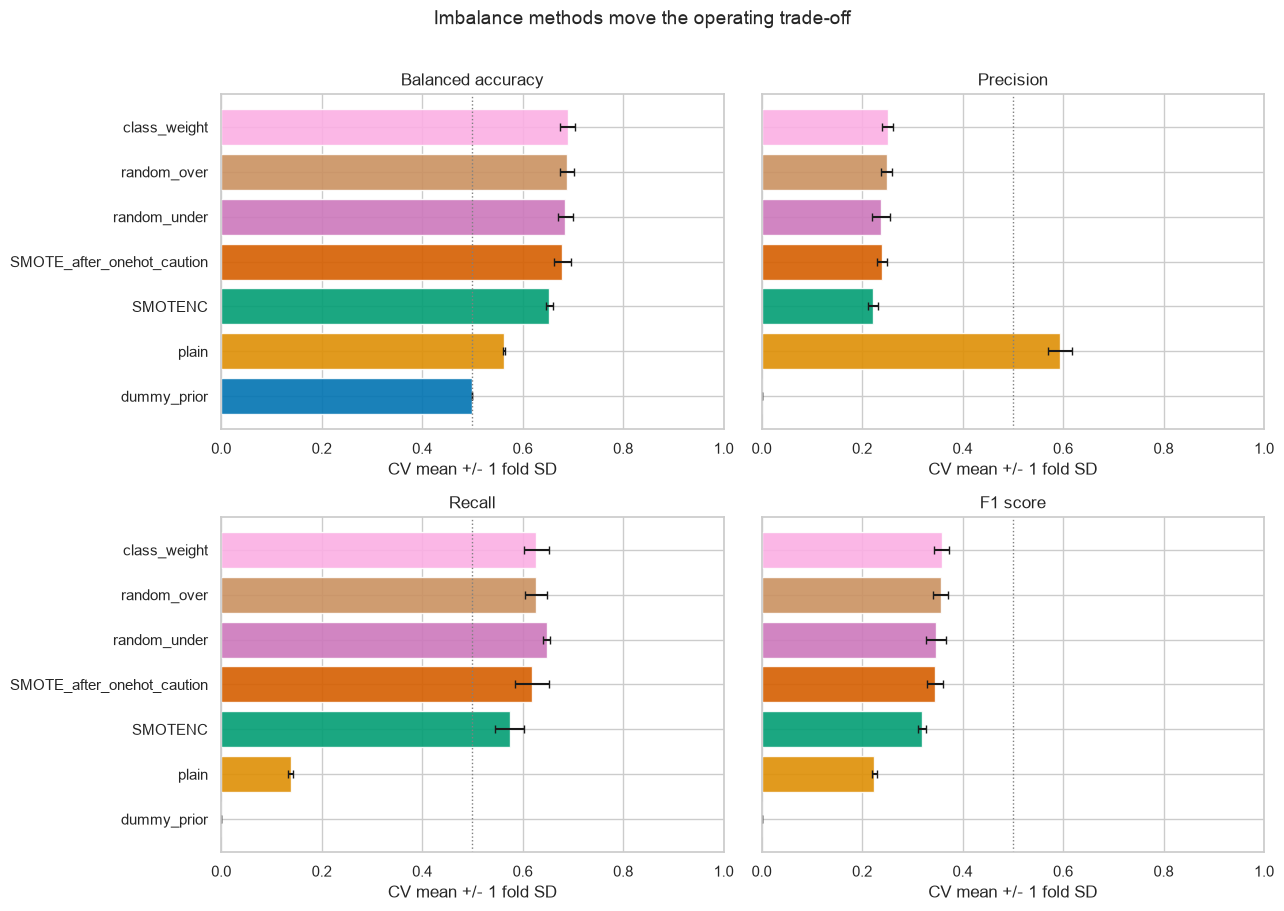

In [7]:
plot_order = cv_comparison.sort_values("balanced_accuracy_mean", ascending=True).index
metrics_to_plot = ["balanced_accuracy", "precision", "recall", "f1"]
titles = ["Balanced accuracy", "Precision", "Recall", "F1 score"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
colors = sns.color_palette("colorblind", n_colors=len(plot_order))
for ax, metric, title in zip(axes.flat, metrics_to_plot, titles):
    means = cv_comparison.loc[plot_order, f"{metric}_mean"]
    errors = cv_comparison.loc[plot_order, f"{metric}_std"]
    ax.barh(plot_order, means, xerr=errors, color=colors, alpha=.9, capsize=3)
    ax.set(title=title, xlabel="CV mean +/- 1 fold SD", xlim=(0, 1))
    ax.axvline(.5, color="grey", linestyle=":", linewidth=1)
fig.suptitle("Imbalance methods move the operating trade-off", fontsize=14, y=1.01)
plt.tight_layout()


## Threshold adjustment on out-of-fold predictions

A model can rank customers well while using a poor default threshold. We choose a threshold using out-of-fold predictions on the development data, then evaluate that choice once on validation.

The cost formula below is deliberately simple: one false positive costs `1`, and one false negative costs `5`. These are teaching assumptions. In real work, replace them with stakeholder-approved costs and capacity limits.


In [8]:
def operational_metrics(y_true, probability, threshold=0.5):
    prediction = np.asarray(probability) >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {
        "log_loss": log_loss(y_true, probability),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "cost": float(fp + 5 * fn),
    }

plain_for_threshold = clone(candidates["plain"])
oof_probability = cross_val_predict(
    plain_for_threshold, X_dev, y_dev, cv=cv, method="predict_proba", n_jobs=-1,
)[:, 1]
threshold_candidates = threshold_table(y_dev, oof_probability)
selected = threshold_candidates.sort_values(["cost", "threshold"]).iloc[0]
selected_threshold = float(selected["threshold"])
print(f"OOF development cost-selected threshold: {selected_threshold:.2f}")

validation_rows = []
fitted = {}
for name in ["dummy_prior", "plain", "class_weight", "random_over"]:
    fitted[name] = candidates[name].fit(X_dev, y_dev)
    probability = fitted[name].predict_proba(X_val)[:, 1]
    validation_rows.append({"method": name, **operational_metrics(y_val, probability)})
validation_comparison = pd.DataFrame(validation_rows).set_index("method")
display(validation_comparison.round(4))

plain_probability = fitted["plain"].predict_proba(X_val)[:, 1]
threshold_validation = pd.DataFrame({
    "plain@0.50": operational_metrics(y_val, plain_probability, .5),
    "plain@OOF-selected": operational_metrics(y_val, plain_probability, selected_threshold),
}).T
display(threshold_validation.round(4))


OOF development cost-selected threshold: 0.17


,log_loss,precision,recall,specificity,cost
method,,,,,
dummy_prior,0.3609,0.0000,0.0000,1.0000,2340.0
plain,0.3029,0.6148,0.1603,0.9867,2012.0
class_weight,0.5657,0.2515,0.6218,0.7548,1751.0
random_over,0.5667,0.2496,0.6197,0.7531,1762.0


,log_loss,precision,recall,specificity,cost
plain@0.50,0.3029,0.6148,0.1603,0.9867,2012.0
plain@OOF-selected,0.3029,0.3931,0.5150,0.8947,1507.0


The confusion matrices translate metric changes into counts. This is often the most useful view for non-technical stakeholders because it shows the actual operational burden: extra calls versus missed subscribers.


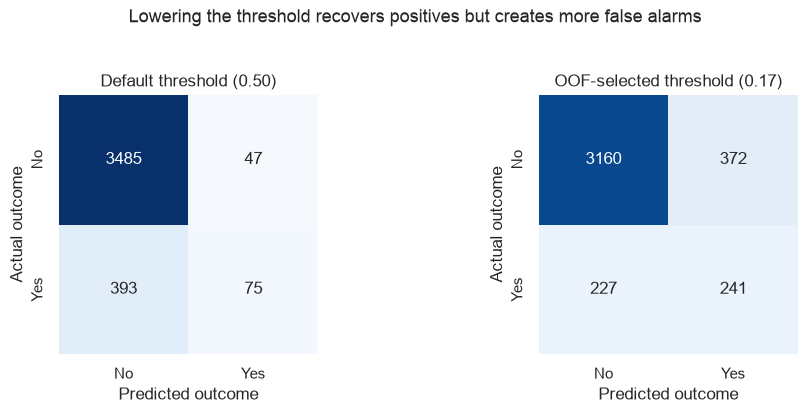

In [9]:
validation_predictions = {
    "Default threshold (0.50)": plain_probability >= 0.50,
    f"OOF-selected threshold ({selected_threshold:.2f})": plain_probability >= selected_threshold,
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmax = max(confusion_matrix(y_val, pred, labels=[0, 1]).max()
           for pred in validation_predictions.values())
for ax, (title, prediction) in zip(axes, validation_predictions.items()):
    matrix = confusion_matrix(y_val, prediction, labels=[0, 1])
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
                vmin=0, vmax=vmax, square=True, ax=ax,
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    ax.set(title=title, xlabel="Predicted outcome", ylabel="Actual outcome")
fig.suptitle("Lowering the threshold recovers positives but creates more false alarms",
             fontsize=13, y=1.03)
plt.tight_layout()


This threshold curve should be read as a decision tool, not as a search for a universal constant. If campaign cost, customer fatigue, or team capacity changes, the threshold should be revisited using the same validation discipline.


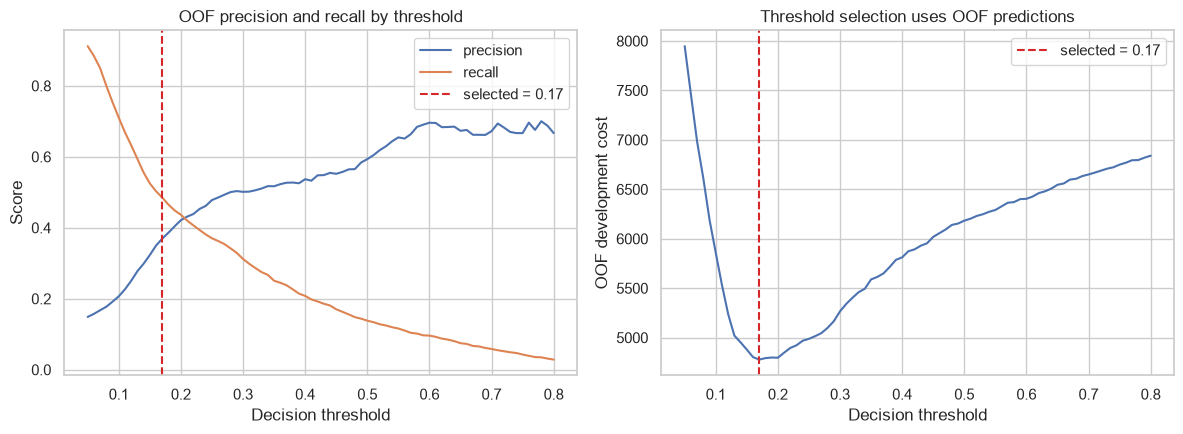

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(threshold_candidates["threshold"], threshold_candidates["precision"], label="precision")
axes[0].plot(threshold_candidates["threshold"], threshold_candidates["recall"], label="recall")
axes[0].axvline(selected_threshold, color="tab:red", linestyle="--",
                label=f"selected = {selected_threshold:.2f}")
axes[0].legend()
axes[0].set(xlabel="Decision threshold", ylabel="Score",
            title="OOF precision and recall by threshold")

axes[1].plot(threshold_candidates["threshold"], threshold_candidates["cost"])
axes[1].axvline(selected_threshold, color="tab:red", linestyle="--",
                label=f"selected = {selected_threshold:.2f}")
axes[1].set(xlabel="Decision threshold", ylabel="OOF development cost",
            title="Threshold selection uses OOF predictions")
axes[1].legend()
plt.tight_layout()


## Probability calibration

Resampling and class weighting change what the model sees during fitting. That can be useful for classification, but the predicted probabilities may no longer match real deployment prevalence. If probabilities drive expected-value decisions, calibration matters.


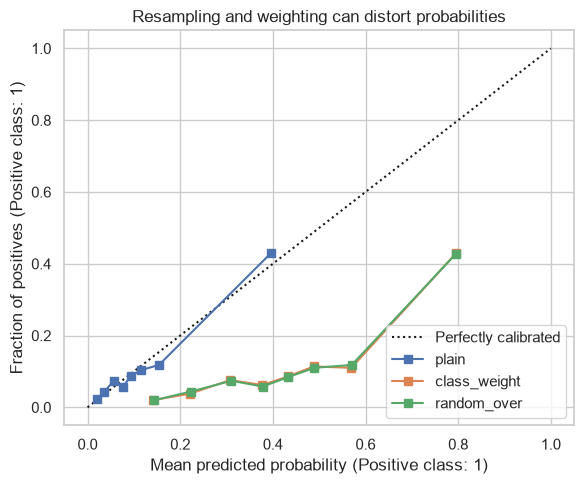

In [11]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(6, 5))
for name in ["plain", "class_weight", "random_over"]:
    probability = fitted[name].predict_proba(X_val)[:, 1]
    CalibrationDisplay.from_predictions(
        y_val, probability, n_bins=8, strategy="quantile", name=name, ax=ax)
ax.set_title("Resampling and weighting can distort probabilities")
plt.tight_layout()


## Interpretation and practical recommendation

What this experiment establishes:

- **Classification behavior:** class weighting and resampling usually increase recall, but they often reduce precision.
- **Probability behavior:** log loss and calibration can worsen even when recall improves.
- **Complexity:** class weighting and threshold adjustment are simple to explain and maintain; SMOTENC is more specialized and should be justified by a clear gain.
- **Validation discipline:** the threshold was chosen from out-of-fold development predictions and checked once on validation. Repeatedly tuning after seeing validation performance would leak validation feedback into model selection.

**Practical recommendation:** use plain logistic regression as the maintainable baseline, then first try threshold adjustment or `class_weight="balanced"` before deploying synthetic sampling. Consider SMOTENC only when it improves the chosen operating metric enough to justify the added complexity and calibration risk.

For deployment, log the dataset hash, split seed, package versions, candidate parameters, fold-level scores, selected threshold, cost assumptions, and the serialized end-to-end pipeline. Monitor both prevalence and calibration after launch.

**When not to synthesize:** avoid SMOTE-style methods when neighborhoods are not meaningful, minority labels are noisy, constraints can be violated, categories have high cardinality, time order matters, or calibrated probabilities are central and recalibration data are scarce.


## Common mistakes and leakage warnings

- Resampling once before cross-validation or before the train/validation split.
- Fitting imputers, scalers, or encoders outside the pipeline before CV.
- Applying ordinary SMOTE to raw ordinal category codes and treating the codes as distances.
- Reporting recall at threshold `0.50` while ignoring precision, cost, and calibration.
- Assuming the balanced training distribution is the deployment prevalence.
- Tuning sampling strategy and threshold on the test set.

## Exercises

1. Vary `sampling_strategy` for random oversampling and plot balanced accuracy versus log loss.
2. Replace logistic regression with a tree-based model and compare speed, recall, precision, and maintainability.
3. Calibrate the class-weighted model using a dedicated calibration split; compare reliability curves and log loss.
4. Add bootstrap confidence intervals for validation precision, recall, and business cost.
5. **Challenge:** design a repeated nested-CV experiment comparing threshold tuning with SMOTENC under a fixed business cost.

## Summary

Class weighting and resampling change the fitting problem; threshold adjustment changes the decision rule. None is automatically best. In practical ML, the recommendation should balance performance, simplicity, speed, maintainability, probability quality, and the real cost of mistakes.

## References

- [imbalanced-learn pipeline](https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html)
- [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)
- [SMOTENC](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTENC.html)
